# Fine-Tuning TrOCR for Doctor's Handwritten Prescription Recognition

## Project Objective

This project aims to fine-tune Microsoft's TrOCR model on the Doctor's Handwritten Prescription BD Dataset to accurately recognize handwritten medicine names from doctor prescriptions.

### Model
- TrOCR Base

### Framework
- PyTorch
- Hugging Face Transformers

### Dataset
- Doctor's Handwritten Prescription BD Dataset

### Author
- Daniyal

In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
!pip install -q transformers datasets evaluate accelerate
!pip install -q kagglehub
!pip install -q sentencepiece
!pip install -q opencv-python
!pip install -q jiwer

In [ ]:
# ================================
# Import Libraries
# ================================

import os
import random
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch

from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel
)

warnings.filterwarnings("ignore")

In [ ]:
# ================================
# Set Random Seed
# ================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random Seed:", SEED)

Random Seed: 42


In [ ]:
# ================================
# Download Dataset
# ================================

import kagglehub

dataset_path = kagglehub.dataset_download(
    "mamun1113/doctors-handwritten-prescription-bd-dataset"
)

print("Dataset downloaded to:")
print(dataset_path)

Dataset downloaded to:
/root/.cache/kagglehub/datasets/mamun1113/doctors-handwritten-prescription-bd-dataset/versions/1


In [ ]:
# ================================
# Explore Dataset
# ================================

for root, dirs, files in os.walk(dataset_path):
    print(root)
    print(f"Folders : {len(dirs)}")
    print(f"Files   : {len(files)}")
    print("-"*60)


/root/.cache/kagglehub/datasets/mamun1113/doctors-handwritten-prescription-bd-dataset/versions/1
Folders : 1
Files   : 0
------------------------------------------------------------
/root/.cache/kagglehub/datasets/mamun1113/doctors-handwritten-prescription-bd-dataset/versions/1/Doctor’s Handwritten Prescription BD dataset
Folders : 3
Files   : 0
------------------------------------------------------------
/root/.cache/kagglehub/datasets/mamun1113/doctors-handwritten-prescription-bd-dataset/versions/1/Doctor’s Handwritten Prescription BD dataset/Validation
Folders : 1
Files   : 1
------------------------------------------------------------
/root/.cache/kagglehub/datasets/mamun1113/doctors-handwritten-prescription-bd-dataset/versions/1/Doctor’s Handwritten Prescription BD dataset/Validation/validation_words
Folders : 0
Files   : 780
------------------------------------------------------------
/root/.cache/kagglehub/datasets/mamun1113/doctors-handwritten-prescription-bd-dataset/versions/1

In [ ]:
import os

base_path = dataset_path + "/Doctor’s Handwritten Prescription BD dataset"

print(os.listdir(base_path + "/Training"))
print(os.listdir(base_path + "/Validation"))
print(os.listdir(base_path + "/Testing"))

['training_labels.csv', 'training_words']
['validation_words', 'validation_labels.csv']
['testing_labels.csv', 'testing_words']


In [ ]:
# ===========================================
# Load CSV Files
# ===========================================

train_df = pd.read_csv(
    base_path + "/Training/training_labels.csv"
)

val_df = pd.read_csv(
    base_path + "/Validation/validation_labels.csv"
)

test_df = pd.read_csv(
    base_path + "/Testing/testing_labels.csv"
)

print("Training Shape :", train_df.shape)
print("Validation Shape :", val_df.shape)
print("Testing Shape :", test_df.shape)


# df = pd.concat([train_df, val_df, test_df], axis=0)

# print("Total Shape :", df)

# train_df.head(5)

Training Shape : (3120, 3)
Validation Shape : (780, 3)
Testing Shape : (780, 3)


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3120 entries, 0 to 3119
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   IMAGE          3120 non-null   object
 1   MEDICINE_NAME  3120 non-null   object
 2   GENERIC_NAME   3120 non-null   object
dtypes: object(3)
memory usage: 73.3+ KB


In [ ]:
# train_df.isnull()
train_df.columns

Index(['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME'], dtype='object')

In [ ]:
train_df["GENERIC_NAME"].head(200)


,GENERIC_NAME
0,Paracetamol
1,Paracetamol
2,Paracetamol
3,Paracetamol
4,Paracetamol
...,...
195,Cetirizine Hydrochloride
196,Cetirizine Hydrochloride
197,Cetirizine Hydrochloride
198,Cetirizine Hydrochloride


In [ ]:
train_df.sample(10)

,IMAGE,MEDICINE_NAME,GENERIC_NAME
2898,2898.png,Tamen,Paracetamol
2976,2976.png,Tridosil,Azithromycin Dihydrate
2130,2130.png,Montex,Montelukast Sodium
214,214.png,Axodin,Fexofenadine Hydrochloride
1068,1068.png,Esoral,Esomeprazole
2184,2184.png,Napa Extend,Paracetamol
969,969.png,Disopan,Clonazepam
3004,3004.png,Trilock,Montelukast Sodium
2944,2944.png,Telfast,Fexofenadine Hydrochloride
2507,2507.png,Opton,Esomeprazole


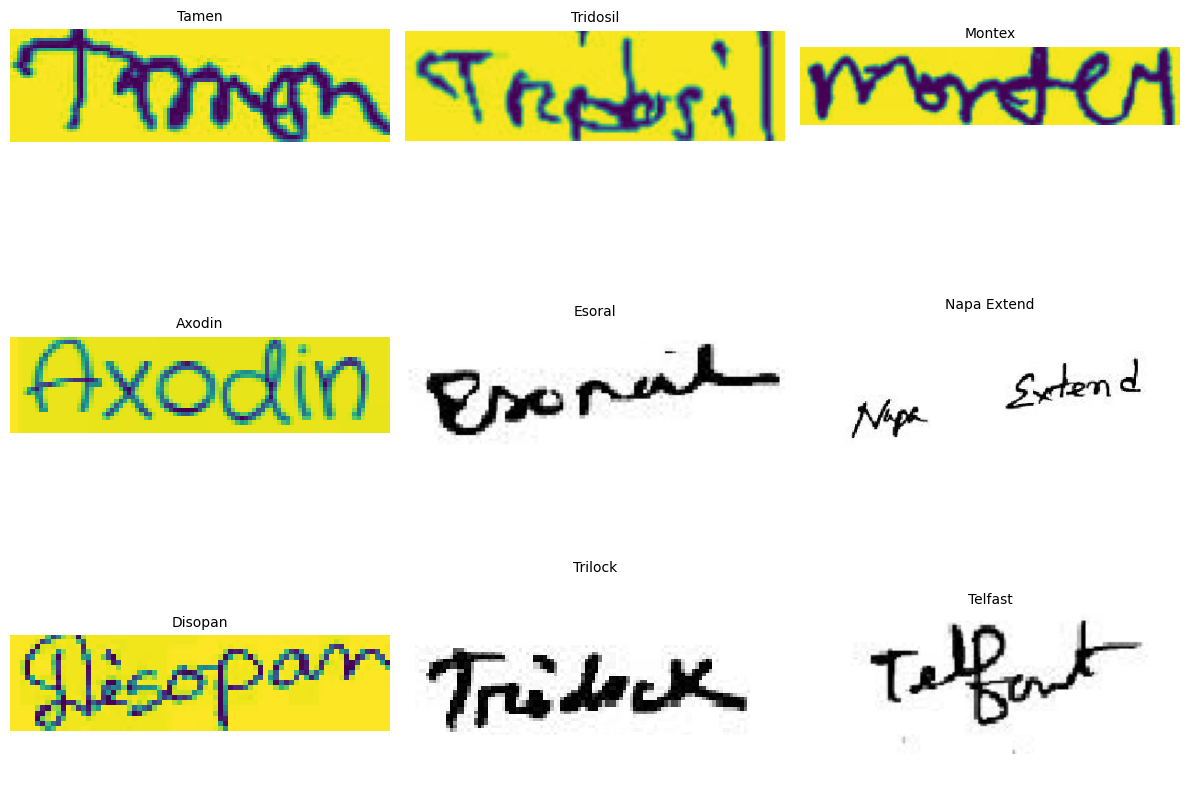

In [ ]:
# ==========================================
# Display Random Training Samples
# ==========================================

import matplotlib.pyplot as plt
from PIL import Image
import random
import os

train_image_dir = os.path.join(
    base_path,
    "Training",
    "training_words"
)

samples = train_df.sample(9, random_state=42)

plt.figure(figsize=(12,10))

for i, (_, row) in enumerate(samples.iterrows()):

    img_path = os.path.join(train_image_dir, row["IMAGE"])

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(row["MEDICINE_NAME"], fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# Check Image Properties
# ==========================================

sample = train_df.iloc[0]

img_path = os.path.join(train_image_dir, sample["IMAGE"])

img = Image.open(img_path)

print("Image Size :", img.size)
print("Image Mode :", img.mode)
print("Image Format :", img.format)

Image Size : (238, 92)
Image Mode : RGB
Image Format : PNG


In [ ]:
# ==========================================
# Check for Corrupted Images
# ==========================================

bad_images = []

for img_name in train_df["IMAGE"]:

    try:
        img = Image.open(os.path.join(train_image_dir, img_name))
        img.verify()

    except Exception:
        bad_images.append(img_name)

print(f"Broken Images : {len(bad_images)}")

Broken Images : 0


In [ ]:
# ==========================================
# Load TrOCR Processor & Model
# ==========================================
import torch

from transformers import TrOCRProcessor, VisionEncoderDecoderModel

MODEL_NAME = "microsoft/trocr-base-handwritten"

processor = TrOCRProcessor.from_pretrained(MODEL_NAME)

model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)

print("Model Loaded Successfully!")
print("Using Device:", device)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model Loaded Successfully!
Using Device: cuda


In [ ]:
# ==========================================
# Select One Sample
# ==========================================

sample = train_df.sample(1, random_state=42).iloc[0]

image_path = os.path.join(train_image_dir, sample["IMAGE"])

print("Image File      :", sample["IMAGE"])
print("Ground Truth    :", sample["MEDICINE_NAME"])
print("Generic Name    :", sample["GENERIC_NAME"])

Image File      : 2898.png
Ground Truth    : Tamen
Generic Name    : Paracetamol


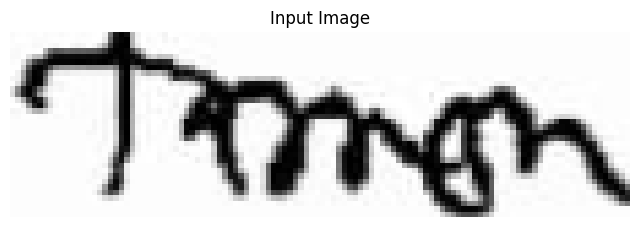

In [ ]:
# ==========================================
# Display Image
# ==========================================

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(8,3))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [ ]:
# ==========================================
# Process Image
# ==========================================

pixel_values = processor(
    images=image,
    return_tensors="pt"
).pixel_values

pixel_values = pixel_values.to(device)

print(pixel_values.shape)

torch.Size([1, 3, 384, 384])


In [ ]:
# ==========================================
# Predict Text
# ==========================================

generated_ids = model.generate(pixel_values)

prediction = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("=" * 40)
print("Ground Truth :", sample["MEDICINE_NAME"])
print("Prediction   :", prediction)
print("=" * 40)

Ground Truth : Tamen
Prediction   : tarnen .


In [ ]:
def char_accuracy(gt, pred):
    gt = gt.lower()
    pred = pred.lower()

    correct = 0
    total = max(len(gt), len(pred))

    for i in range(min(len(gt), len(pred))):
        if gt[i] == pred[i]:
            correct += 1

    return correct / total * 100


gt = "Tamen"
pred = "tarnen"

score = char_accuracy(gt, pred)

print("Ground Truth :", gt)
print("Prediction   :", pred)
print(f"Char Accuracy: {score:.2f}%")

Ground Truth : Tamen
Prediction   : tarnen
Char Accuracy: 33.33%


In [ ]:
from torch.utils.data import Dataset

class PrescriptionDataset(Dataset):
    def __init__(self, df, image_dir, processor):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        img_path = os.path.join(self.image_dir, row["IMAGE"])
        image = Image.open(img_path).convert("RGB")

        text = row["MEDICINE_NAME"]

        # image → tensor
        pixel_values = self.processor(
            images=image,
            return_tensors="pt"
        ).pixel_values.squeeze()

        # text → token ids
        labels = self.processor.tokenizer(
            text,
            return_tensors="pt"
        ).input_ids.squeeze()

        return {
            "pixel_values": pixel_values,
            "labels": labels
        }



In [ ]:
import torch

def collate_fn(batch):
    pixel_values = torch.stack([item["pixel_values"] for item in batch])

    labels = [item["labels"] for item in batch]

    labels = torch.nn.utils.rnn.pad_sequence(
        labels,
        batch_first=True,
        padding_value=processor.tokenizer.pad_token_id
    )

    return {
        "pixel_values": pixel_values,
        "labels": labels
    }

In [ ]:
import os

base_path = "/root/.cache/kagglehub/datasets/mamun1113/doctors-handwritten-prescription-bd-dataset/versions/1/Doctor’s Handwritten Prescription BD dataset"

train_image_dir = os.path.join(base_path, "Training", "training_words")
val_image_dir = os.path.join(base_path, "Validation", "validation_words")
test_image_dir = os.path.join(base_path, "Testing", "testing_words")

print(train_image_dir)
print(val_image_dir)
print(test_image_dir)

/root/.cache/kagglehub/datasets/mamun1113/doctors-handwritten-prescription-bd-dataset/versions/1/Doctor’s Handwritten Prescription BD dataset/Training/training_words
/root/.cache/kagglehub/datasets/mamun1113/doctors-handwritten-prescription-bd-dataset/versions/1/Doctor’s Handwritten Prescription BD dataset/Validation/validation_words
/root/.cache/kagglehub/datasets/mamun1113/doctors-handwritten-prescription-bd-dataset/versions/1/Doctor’s Handwritten Prescription BD dataset/Testing/testing_words


In [ ]:
train_dataset = PrescriptionDataset(
    train_df,
    train_image_dir,
    processor
)

val_dataset = PrescriptionDataset(
    val_df,
    val_image_dir,
    processor
)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
sample = train_dataset[0]

print(sample.keys())
print(sample["pixel_values"].shape)
print(sample["labels"])

dict_keys(['pixel_values', 'labels'])
torch.Size([3, 384, 384])
tensor([    0, 26145,  8152,     2])


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn   # 👈 THIS IS THE KEY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn   # 👈 ALSO HERE
)

In [ ]:
batch = next(iter(train_loader))

print(batch.keys())

print("Pixel values shape:", batch["pixel_values"].shape)
print("Labels shape:", batch["labels"].shape)

dict_keys(['pixel_values', 'labels'])
Pixel values shape: torch.Size([8, 3, 384, 384])
Labels shape: torch.Size([8, 6])


In [ ]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=5e-5)

model.train()

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (i

In [ ]:
from torch.optim import AdamW

optimizer = AdamW(
    model.parameters(),
    lr=5e-5
)

model.train()

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (i

In [ ]:
batch = next(iter(train_loader))

print(batch["pixel_values"].shape)
print(batch["labels"].shape)

torch.Size([8, 3, 384, 384])
torch.Size([8, 5])


In [ ]:
print(batch["labels"][0])

tensor([   0,  597, 3463,  139,    2])


In [ ]:
decoded = processor.tokenizer.decode(
    batch["labels"][0],
    skip_special_tokens=True
)

print(decoded)

Fexo


In [ ]:
print("Pad Token:", processor.tokenizer.pad_token)
print("Pad Token ID:", processor.tokenizer.pad_token_id)

print("CLS Token:", processor.tokenizer.cls_token)
print("CLS Token ID:", processor.tokenizer.cls_token_id)

print("SEP Token:", processor.tokenizer.sep_token)
print("SEP Token ID:", processor.tokenizer.sep_token_id)

Pad Token: <pad>
Pad Token ID: 1
CLS Token: <s>
CLS Token ID: 0
SEP Token: </s>
SEP Token ID: 2


In [ ]:
import transformers
import torch

print("Transformers:", transformers.__version__)
print("PyTorch:", torch.__version__)

Transformers: 4.53.3
PyTorch: 2.11.0+cu128


In [ ]:
# !pip uninstall -y transformers
# !pip install transformers==4.53.3

In [ ]:
print(model.config.to_dict().keys())

dict_keys(['return_dict', 'output_hidden_states', 'torchscript', 'torch_dtype', 'use_bfloat16', 'tf_legacy_loss', 'pruned_heads', 'tie_word_embeddings', 'chunk_size_feed_forward', 'is_encoder_decoder', 'is_decoder', 'cross_attention_hidden_size', 'add_cross_attention', 'tie_encoder_decoder', 'max_length', 'min_length', 'do_sample', 'early_stopping', 'num_beams', 'num_beam_groups', 'diversity_penalty', 'temperature', 'top_k', 'top_p', 'typical_p', 'repetition_penalty', 'length_penalty', 'no_repeat_ngram_size', 'encoder_no_repeat_ngram_size', 'bad_words_ids', 'num_return_sequences', 'output_scores', 'return_dict_in_generate', 'forced_bos_token_id', 'forced_eos_token_id', 'remove_invalid_values', 'exponential_decay_length_penalty', 'suppress_tokens', 'begin_suppress_tokens', 'architectures', 'finetuning_task', 'id2label', 'label2id', 'tokenizer_class', 'prefix', 'bos_token_id', 'pad_token_id', 'eos_token_id', 'sep_token_id', 'decoder_start_token_id', 'task_specific_params', 'problem_type'

In [ ]:
from tqdm.auto import tqdm

start_epoch =  3

model.train()

for epoch in range(start_epoch):

    total_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}")

    for batch in progress_bar:

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            pixel_values=pixel_values,
            labels=labels
        )

        loss = outputs.loss

        loss.backward()

        optimizer.step()

        optimizer.zero_grad()

        total_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)

    print(f"\nEpoch {epoch} Average Loss: {avg_loss:.4f}")

Epoch 0:   0%|          | 0/390 [00:00<?, ?it/s]


Epoch 0 Average Loss: 0.0951


Epoch 1:   0%|          | 0/390 [00:00<?, ?it/s]


Epoch 1 Average Loss: 0.0444


Epoch 2:   0%|          | 0/390 [00:00<?, ?it/s]

In [1]:
SAVE_PATH = "/content/trocr_prescription_model"

model.save_pretrained(SAVE_PATH)
processor.save_pretrained(SAVE_PATH)

print("✅ Model saved successfully!")

NameError: name 'model' is not defined